In [1]:
import os, sys
import time
import matplotlib.pyplot as plt
import numpy as np
try:
    import pySIMsalabim as sim
except ImportError: # add parent directory to sys.path if pySIMsalabim is not installed
    sys.path.append('../..')
    import pySIMsalabim as sim
from pySIMsalabim.experiments import impls


In [2]:
# Set the path to the simulation setup file 
cwd = os.path.abspath('..')
session_path = os.path.join(cwd, 'ZimT')
zimt_device_parameters = os.path.join(session_path, 'simulation_setup.txt')

In [3]:
# Set the simulation parameters 
tVG_name = os.path.join(session_path, 'tVG.txt')
f_min = 1e-2
f_max = 1e10
f_steps = 20
V = 0.0
G_frac = 1 
GStep = 0.05

In [4]:
# Set args to modify 
# IMPLS_args = {'cmd_pars': [
#     {'par': 'l1.N_c', 'val': '2.2E22'},
#     {'par': 'l3.N_c', 'val': '2.2E22'}
# ]}

In [5]:
# Try runnin the experiment with the modified arguments
# Run the IMPLS simulation
t_0 = time.perf_counter()
ret, mess = impls.run_IMPLS_simu(zimt_device_parameters, session_path, f_min, f_max, f_steps, V, G_frac, GStep, tVG_name=tVG_name, output_file="freqP.dat", tj_name='tj.dat', varFile='varFile.dat', verbose=True)
t_1 = time.perf_counter()

In [6]:
# Let's look at the recombination/photoluminescence data up until termination
import pandas as pd

data = pd.read_csv('varFile.dat', sep=r'\s+')

# Integrate direct recombination over x, position within the material 
data = impls.integrate_fxt_dx(data, 'Rdir', x_name='x', t_name='time')

In [7]:
# Find the number of non-convergent runs 
divergent_count = 0

log = open("log.txt", "r")

for line in log:
    # Remove leading spaces and new line char
    line = line.strip()
    line = line.split(" ")
    
    if "Skipping" in line:
        divergent_count += 1

In [8]:
# Print General Runtime stats to get some idea of where the simulation got to

t_max_actual = data['time'].iloc[-1]
t_max_target = 1/f_min 

print("**TIME**")
print(f"Max Simulated Time: {t_max_actual}s")
print(f"Target Max Simulation Time: {t_max_target}s")

no_loops_completed = data["time"].count()
total_no_loops_run = no_loops_completed + divergent_count

print("**CONVERGENCE**")
print(f"Total Number of Time Steps Simulated: {total_no_loops_run}")
print(f"No Divergent Timesteps: {divergent_count}")
print(f"Divergence Percentage: {divergent_count/total_no_loops_run*100:.3}%")

**TIME**
Max Simulated Time: 100.8s
Target Max Simulation Time: 100.0s
**CONVERGENCE**
Total Number of Time Steps Simulated: 1548
No Divergent Timesteps: 0
Divergence Percentage: 0.0%


In [9]:
# Run the IMPLS code on the recombination data to get the IMPLS transfer function P
result, message = impls.get_IMPLS(data, f_min, f_max, f_steps, session_path, 'freqP.dat')

KeyError: 't'

In [ ]:
# Read in the IMPLS data
impls_data = pd.read_csv('freqP.dat', sep=r'\s+')
impls_data.head()

,freq,ReP,ImP
0,9.157509e+09,6.246684e+13,6.543273e+12
1,8.090615e+09,6.200642e+13,8.230864e+12
2,7.147963e+09,6.142771e+13,1.011549e+13
3,6.321113e+09,6.068249e+13,1.240599e+13
4,5.595971e+09,5.978377e+13,1.494599e+13


In [ ]:
impls_data.tail()

,freq,ReP,ImP
228,0.015038,-3.110452e+19,1.361672e+13
229,0.013353,-3.110452e+19,1.209076e+13
230,0.011857,-3.110452e+19,1.073682e+13
231,0.010529,-3.110452e+19,9.533234e+12
232,0.009921,-3.110452e+19,8.981928e+12


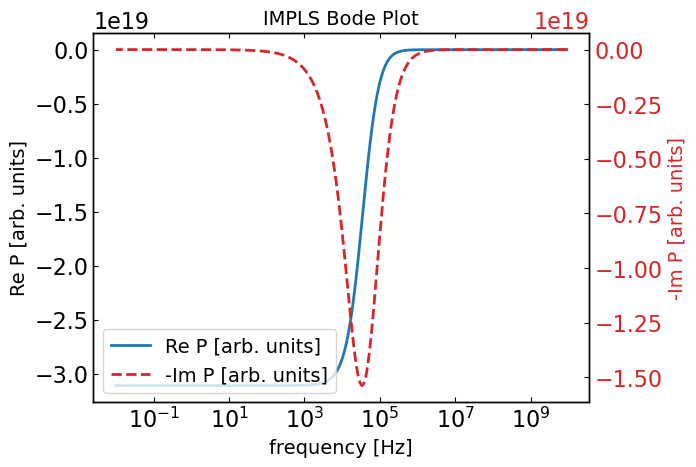

In [ ]:
# Plot corresponding graphs
# impls.plot_IMPLS(session_path, output_file='freqP.dat')
impls.IMPLS_plot(session_path, output_file='freqP.dat', xscale='log', yscale1='linear', yscale2='linear')

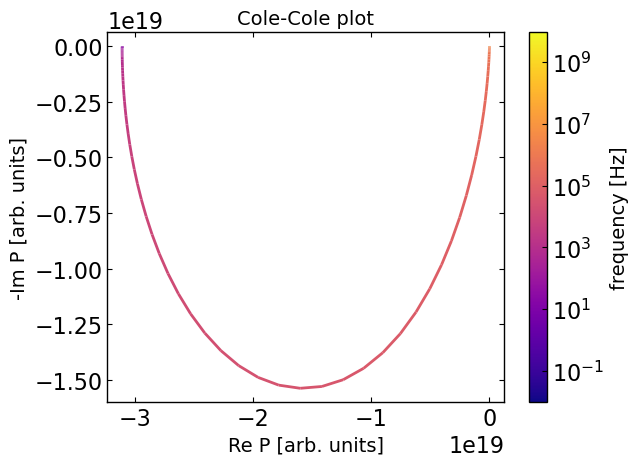

In [ ]:
# Plot the Bode Plot 
impls.ColeCole_plot(session_path, output_file='freqP.dat')

In [ ]:
# Find the characteristic frequency 
max_ImP = impls_data['ImP'].abs().max()
max_row = impls_data[impls_data['ImP'].abs()==max_ImP]
max_freq = max_row['freq']

# Frequency as suggested by recombination and generation 
G = 1E27
k_dir = 1E-17
f = 2*np.sqrt(G*k_dir)

# Alternative formula 
N_c = 2.2E24 #m^-3, DOS of conduction and valence bands
E_g = 2 #eV
k_B = 1.38E-23 # Boltzman constant 
T = 295 #Kelvin
q_e = 1.6E-19

n_i = np.sqrt((N_c**2)*np.exp(-(E_g*q_e)/(k_B*T)))
f_guess = 2*k_dir*n_i

print(np.exp(-(E_g*q_e)/(k_B*T)))

print(f'RC frequency: {2*np.pi*max_freq.values[0]:.2} Hz')
print(f'1/(Carrier Lifetime): {f:.2} Hz')
print(f'1/Carrier Lifetime using n_i: {f_guess:.2} Hz')

7.284238037893141e-35
RC frequency: 2.1e+05 Hz
1/(Carrier Lifetime): 2e+05 Hz
1/Carrier Lifetime using n_i: 3.8e-10 Hz


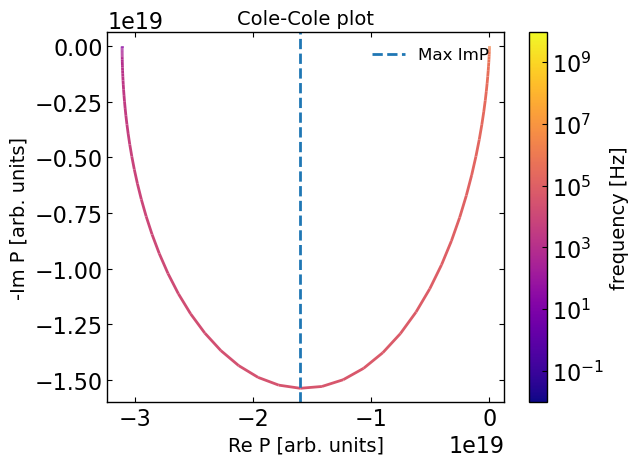

In [ ]:
# Visually check the selected frequency
impls.ColeCole_plot(session_path, output_file='freqP.dat', plot=False)
plt.axvline(max_row['ReP'].values[0], linestyle='--', label='Max ImP')
plt.legend(frameon=False, fontsize=12)
plt.show()

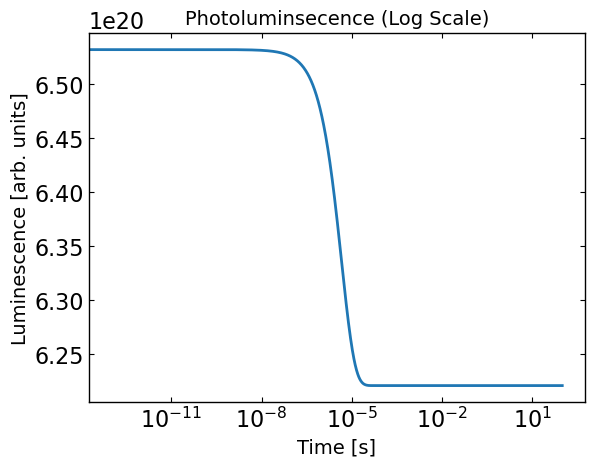

In [ ]:
# Plot Recombination against time 
Jdir = pd.read_csv('tj.dat', sep=r'\s+')[['JdirL1', 'JdirL2', 'JdirL3']]
Rdir = data['Rdir']

plt.plot(data['time'], Rdir)
plt.xscale('log')
plt.xlabel('Time [s]')
plt.ylabel('Luminescence [arb. units]')
plt.title('Photoluminsecence (Log Scale)')
plt.show()

In [ ]:
# Clean up the output files (comment out if you want to keep the output files)
# sim.clean_all_output(session_path)
# sim.clean_up_output('freqY',session_path)
# sim.delete_folders('tmp',session_path)
# sim.clean_up_output('varFile.dat', session_path)
# sim.clean_up_output('freqP.dat', session_path)